# Project 05 - NLP & Transformers: Text Classification & Fine-tuning BERT

We build the intuition of Natural Language Processing with small, runnable demos (a real working
text classifier, a word-importance chart, an embeddings map), then give you the **production code**
to fine-tune a real transformer (BERT) on a **Kaggle GPU**.

**What you'll learn**
- How text becomes numbers (**tokenization**, **bag-of-words/TF-IDF**, **embeddings**).
- A working **text classifier** in a few lines (your bar to beat).
- What **transformers** and **attention** add, and **pretraining vs fine-tuning**.

## The scenario
Your support inbox gets thousands of messages a day. You want to auto-tag each as **positive** or
**negative** so unhappy customers get routed to a human fast. That's **text classification** -
one of the most common real-world NLP tasks. We'll build a simple, strong version now, then show
how a fine-tuned BERT pushes it further.

## Foundations (plain English)
- **Computers need numbers**, so step one is turning text into numbers.
- **Tokenization** splits text into pieces (words or sub-words) and maps each to an id.
- **Bag-of-words / TF-IDF** represents a sentence by which words it contains (TF-IDF down-weights
  common words like "the"). Simple, fast, and a surprisingly strong baseline.
- **Embeddings** represent each word as a vector so that *similar meanings are near each other*
  ("great" near "good"). This captures meaning, which bag-of-words misses.
- **Transformers (BERT)** read a whole sentence at once and use **attention** to understand each
  word *in context* ("bank" in "river bank" vs "savings bank"). They are **pretrained** on huge
  text, then **fine-tuned** cheaply on your small labelled task.

### Cell 1 - imports and a tiny labelled dataset
We hardcode a small set of short reviews labelled 1 (positive) or 0 (negative), so the notebook
runs instantly. For the real project you'd load a big dataset (e.g. IMDB) on Kaggle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

texts = [
 "i love this product it works great", "absolutely fantastic and easy to use",
 "wonderful experience highly recommend", "best purchase i have made this year",
 "great quality and fast delivery", "happy with it works perfectly",
 "excellent value really pleased", "amazing support and a smooth setup",
 "this is good i am satisfied", "delightful and reliable, five stars",
 "terrible it broke after one day", "awful quality very disappointed",
 "worst purchase i regret it", "hate it nothing works at all",
 "bad experience slow and buggy", "horrible support and a painful setup",
 "this is poor i am unhappy", "useless and a complete waste of money",
 "frustrating and unreliable, one star", "do not buy it is a scam"]
labels = [1,1,1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0,0,0]
print(f"{len(texts)} reviews, {sum(labels)} positive / {len(labels)-sum(labels)} negative")

20 reviews, 10 positive / 10 negative


### Cell 2 - tokenization: text -> tokens -> a vocabulary
A simple tokenizer just lowercases and splits on spaces. The set of all tokens is the
**vocabulary**; each token gets an id. (Real transformers use clever *sub-word* tokens so they can
handle words they've never seen, but the idea is the same.)

In [2]:
def tokenize(s): return s.lower().split()
vocab = sorted({t for s in texts for t in tokenize(s)})
token_id = {t:i for i,t in enumerate(vocab)}
print("vocabulary size:", len(vocab))
print("example -> tokens:", tokenize(texts[0]))
print("example -> ids:", [token_id[t] for t in tokenize(texts[0])])

vocabulary size: 78
example -> tokens: ['i', 'love', 'this', 'product', 'it', 'works', 'great']
example -> ids: [34, 37, 64, 48, 36, 75, 28]


### Cell 3 - a real, working text classifier (TF-IDF + logistic regression)
`TfidfVectorizer` turns each sentence into a number vector (which words, weighted), and logistic
regression learns to separate positive from negative. We train it, then classify **brand-new**
sentences it never saw.

In [3]:
clf = Pipeline([("tfidf", TfidfVectorizer()), ("lr", LogisticRegression(max_iter=1000))])
clf.fit(texts, labels)

new = ["this is great i am very happy", "terrible and a waste, i regret buying",
       "the setup was smooth and reliable", "buggy slow and disappointing"]
for s, p in zip(new, clf.predict_proba(new)[:,1]):
    print(f"P(positive)={p:.2f}  ->  {'POSITIVE' if p>0.5 else 'NEGATIVE'}  |  '{s}'")

P(positive)=0.54  ->  POSITIVE  |  'this is great i am very happy'
P(positive)=0.42  ->  NEGATIVE  |  'terrible and a waste, i regret buying'
P(positive)=0.56  ->  POSITIVE  |  'the setup was smooth and reliable'
P(positive)=0.43  ->  NEGATIVE  |  'buggy slow and disappointing'


### Cell 4 - diagram: which words signal positive vs negative?
The model learned a weight per word. The most positive and most negative words show *what it keys
on*. This is a simple form of model **explainability**.

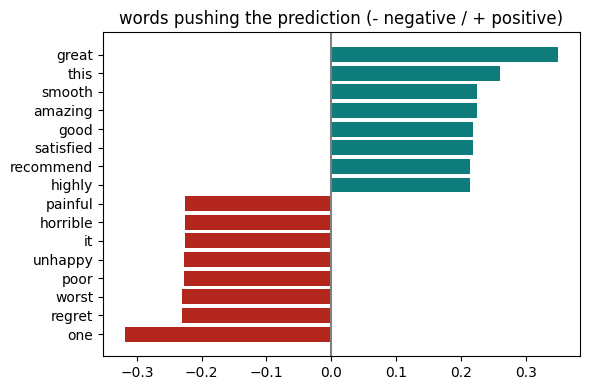

In [4]:
vec = clf.named_steps["tfidf"]; lr = clf.named_steps["lr"]
words = np.array(vec.get_feature_names_out()); coef = lr.coef_[0]
order = np.argsort(coef)
top_neg, top_pos = order[:8], order[-8:]
sel = np.concatenate([top_neg, top_pos])
plt.figure(figsize=(6,4))
plt.barh(words[sel], coef[sel], color=["#b3261e"]*8 + ["#0e7c7b"]*8)
plt.axvline(0, color="grey"); plt.title("words pushing the prediction (- negative / + positive)")
plt.tight_layout(); plt.show()

### Cell 5 - diagram: embeddings (meaning as geometry)
Bag-of-words treats "good" and "great" as unrelated. **Embeddings** place words in space so
similar meanings sit close together. Below is a tiny illustrative map (positive words cluster on
one side, negative on the other) - real models learn 300-to-1000-dimensional versions of this.

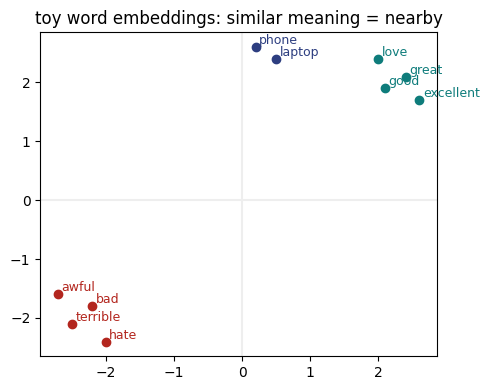

In [5]:
emb = {"good":(2.1,1.9),"great":(2.4,2.1),"excellent":(2.6,1.7),"love":(2.0,2.4),
       "bad":(-2.2,-1.8),"terrible":(-2.5,-2.1),"awful":(-2.7,-1.6),"hate":(-2.0,-2.4),
       "phone":(0.2,2.6),"laptop":(0.5,2.4)}
plt.figure(figsize=(5,4))
for w,(x,y) in emb.items():
    c = "#0e7c7b" if x>1 else ("#b3261e" if x<-1 else "#2d3e80")
    plt.scatter(x,y,color=c); plt.text(x+0.05,y+0.05,w,fontsize=9,color=c)
plt.title("toy word embeddings: similar meaning = nearby"); plt.axhline(0,color="#eee"); plt.axvline(0,color="#eee")
plt.tight_layout(); plt.show()

## The real thing - fine-tune BERT on a Kaggle GPU
TF-IDF + logistic is a strong baseline. To go further you **fine-tune** a pretrained transformer:
it already understands language from pretraining, so it learns your task from relatively little
data. Run this on a Kaggle Notebook with **Accelerator = GPU**.

```python
# Hugging Face transformers + datasets are preinstalled on Kaggle
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer)
import numpy as np, evaluate

ds  = load_dataset("imdb")                                   # or your own CSV
tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")
ds  = ds.map(lambda b: tok(b["text"], truncation=True), batched=True)

model = AutoModelForSequenceClassification.from_pretrained(
            "distilbert-base-uncased", num_labels=2)
acc = evaluate.load("accuracy")
def metrics(p): return acc.compute(
        predictions=np.argmax(p.predictions, axis=1), references=p.label_ids)

args = TrainingArguments("out", per_device_train_batch_size=16,
            num_train_epochs=2, eval_strategy="epoch", report_to="wandb")
Trainer(model, args,
        train_dataset=ds["train"].shuffle(seed=0).select(range(3000)),  # subset = fast
        eval_dataset=ds["test"].select(range(1000)),
        compute_metrics=metrics, tokenizer=tok).train()

model.push_to_hub("your-username/imdb-distilbert")           # share it
```

Then a 3-line live demo (deploy as a Hugging Face Space):
```python
import gradio as gr
from transformers import pipeline
clf = pipeline("text-classification", model="your-username/imdb-distilbert")
gr.Interface(lambda t: clf(t)[0], "text", "json").launch()
```
**Always compare** the fine-tuned model's accuracy to the TF-IDF baseline you built above - only
then do you know the transformer was worth the extra compute.

## What just happened (recap)
- Text becomes numbers via **tokenization** and **TF-IDF**; a logistic model already classifies
  sentiment well (your baseline).
- **Embeddings** capture meaning as geometry (similar words sit close).
- **Transformers (BERT)** read context with **attention** and are **pretrained then fine-tuned** -
  the Kaggle-GPU code does exactly that and ships a live demo.

## Extensions
- **Add classes:** extend to positive/neutral/negative (3 labels).
- **Imbalance:** if 95% of messages are positive, use macro-F1, not accuracy.
- **Beat the baseline:** fine-tune DistilBERT and check it actually beats TF-IDF (sometimes the
  baseline wins on small data - that's a real, useful finding).
- **Next:** Project 06 opens the transformer up and builds **attention from scratch**.

## Mini-glossary
**tokenization** text -> tokens/ids - **vocabulary** all known tokens - **TF-IDF** word-importance
vector - **embedding** meaning as a vector - **transformer/BERT** context-aware language model -
**attention** weighing other words for context - **pretraining vs fine-tuning** learn language
broadly, then specialise cheaply - **encoder** the BERT-style architecture for understanding text.